# Analysis of 10k windows at TSSs

Clustered Nucleosome occupancy changes during S/G2/M to identify possible link between expression level and nucleosome dynamics due to replication effects

### Procedure:
1. Identify highest and lowest expressed genes
2. Collect the chromatin data at TSSes and gene body nucleosome occupancy
3. Cluster on nucleosome occupancy changes per gene
4. Show the relationship between nucleosome occupancy changes with H3K56 acetylation and expression level
5. Perform gene ontology on clusters

### Results:
No relationship was found between acetylation level and nucleosome occupancy variation. It's possible we can choose a more descriptive measure of nucleosome changes that tracks well with acetylation level. There is a stark difference in the highest and lowest expressed genes with respect to nucleosome variability. It appears for the lowest expressed genes, nucleosomes tend to phase out and return by the end of G2/M, likely this is due to replication effects.

### Discussion
- Possible next steps will be to look at subtelomeric genes 20-40k from the ends of each chromosome. These genes will tend to be turned off and whose chromatin is more likely to change because of replication effects. 
- Additionally, we saw previously that H3K56 acetylation may occur and be related to S-phase dynamics near the PAS, end of the gene bodies.
- We will still need to control for the drop in overall reads during S-phase, by either normalizing the deconvolved results, noting in the manuscript the known effect, or identifying and resolving the source of the effect in the model. 


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolve_genome_g0066_10k_10x10_2024_09_20"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [3]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()

In [9]:
from src.reference_data import load_h3k56ac_marks

nuc_h3k56ac_table = load_h3k56ac_marks()
genes_h3k56ac = nuc_h3k56ac_table.loc[~nuc_h3k56ac_table.acc.isna()]
genes_h3k56ac = genes_h3k56ac[['mean_acetylation', 'acc']].groupby('acc').mean()
genes_h3k56ac = genes_h3k56ac.join(genes[['chr', 'strand', 'TSS', 'PAS']], how='inner')
genes_h3k56ac.head()

,mean_acetylation,chr,strand,TSS,PAS
YAL001C,-0.410972,1,-,151205,147540
YAL002W,-0.115362,1,+,143552,147566
YAL003W,0.120556,1,+,142154,143369
YAL005C,-0.145714,1,-,141494,139358
YAL007C,0.220833,1,-,138421,137523


In [10]:
from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)


In [14]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

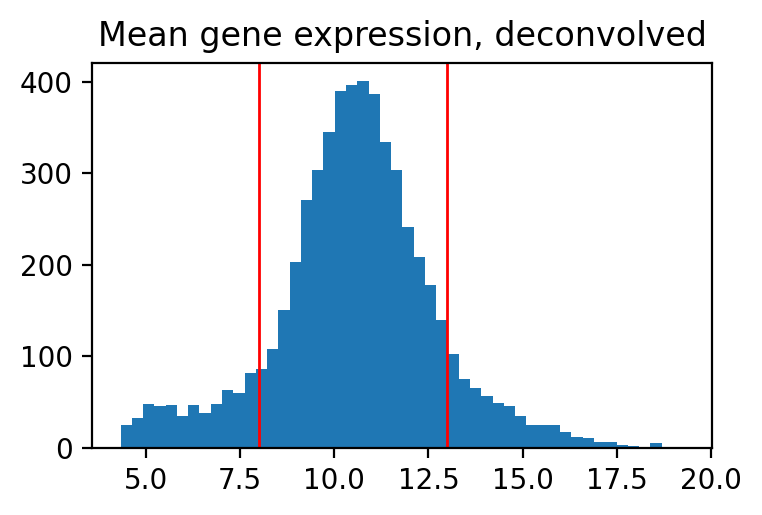

In [17]:
t_indices = gene_clustering.config.get_Hpositions_for_branch('t')
deconvolved_gene_expression_t = gene_clustering.gene_expression[t_indices]
plt.figure(figsize=(4, 2.5))
plt.hist(deconvolved_gene_expression_t.mean(axis=1), bins=50)
plt.title("Mean gene expression, deconvolved")
cutoffs = 8, 13
for cutoff in cutoffs:
    plt.axvline(cutoff, c='red', lw=1)

In [18]:
low_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.max(axis=1) < cutoffs[0]]
high_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.min(axis=1) > cutoffs[1]]
print(f"Low expressed genes: {len(low_tx_genes)}")
print(f"High expressed genes: {len(high_tx_genes)}")

Low expressed genes: 494
High expressed genes: 445


In [19]:
mean_low_tx_genes, low_tx_gb_nuc_occ = \
    analysis.load_stacked_mnase_data_for_genes(low_tx_genes, padding=1000)

Failed to find center key for:  YHR055C
Failed to load 7 files


In [20]:
mean_high_tx_genes, high_tx_gb_nuc_occ = analysis.load_stacked_mnase_data_for_genes(
    high_tx_genes, padding=1000)

In [21]:
normalized_low_tx_gb = (low_tx_gb_nuc_occ - \
    low_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    low_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))

normalized_high_tx_gb = (high_tx_gb_nuc_occ - \
    high_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    high_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))


Text(0.5, 0.98, 'Gene body nucleosome occupancy')

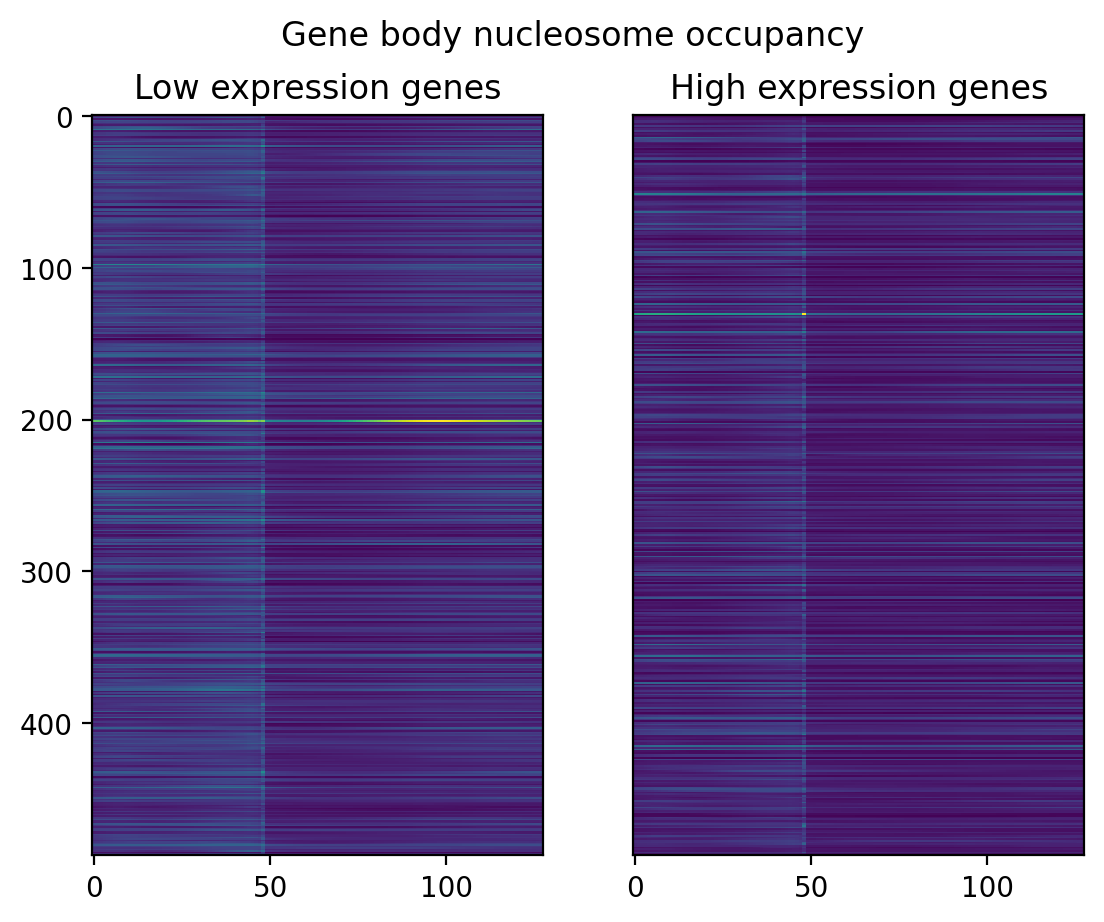

In [22]:
plt.subplot(1, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto')
plt.title("Low expression genes")

plt.subplot(1, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.dropna().astype(float)[t_indices], aspect='auto', 
           interpolation='none')
plt.yticks([])
plt.title("High expression genes")

plt.suptitle("Gene body nucleosome occupancy")

In [24]:
sorted_low_tx_repl = genes_replication.loc[normalized_low_tx_gb.index]\
    .sort_values('replication_time').index
sorted_high_tx_repl = genes_replication.loc[normalized_high_tx_gb.index]\
    .sort_values('replication_time').index

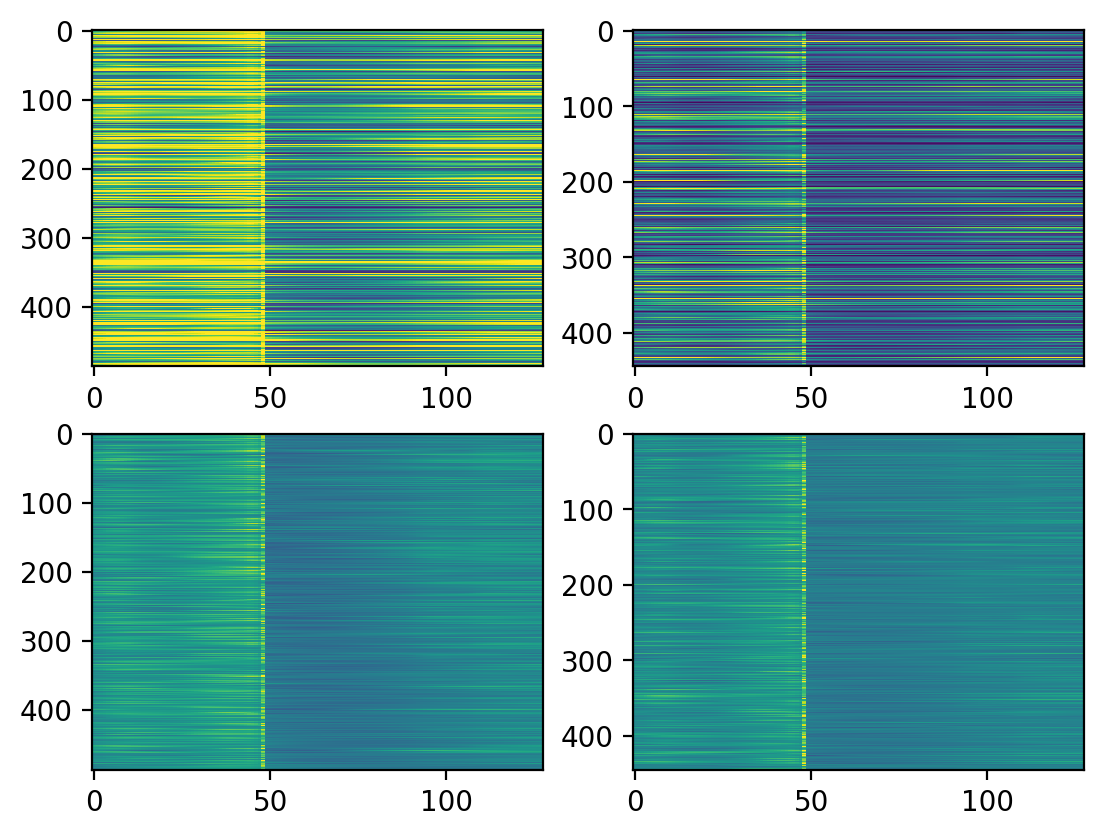

In [25]:
plt.subplot(2, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=0, vmax=500)
plt.subplot(2, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=0, vmax=500)

plt.subplot(2, 2, 3)
plt.imshow(normalized_low_tx_gb.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=-5, vmax=5)
plt.subplot(2, 2, 4)
plt.imshow(normalized_high_tx_gb.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=-5, vmax=5)


In [26]:
from sklearn.cluster import KMeans
n_clusters = 9
def cluster_gb_data(normalized_gb,_gb_nuc_occ):
    kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(
       _gb_nuc_occ.dropna()[t_indices])

    clustered_gb =_gb_nuc_occ.dropna().copy()
    clustered_gb['cluster'] = kmeans.labels_+1
    clustered_gb = clustered_gb.reset_index().set_index(['cluster', 'orf_name'])
    clustered_gb = clustered_gb.sort_index()

    plt.subplot(1, 2, 1)
    plt.imshow(clustered_gb.astype(float)[t_indices],
                         interpolation='none', aspect='auto', vmin=0, vmax=800)
    plt.title("Raw")
    plt.subplot(1, 2, 2)
    plt.imshow(normalized_gb.loc[clustered_gb.reset_index().orf_name][t_indices]\
        .astype(float), aspect='auto', interpolation='none', vmin=-2, vmax=2)
    plt.title("Normalized")
    
    return clustered_gb


Text(0.5, 0.98, 'Lowly expressed genes, n=494')

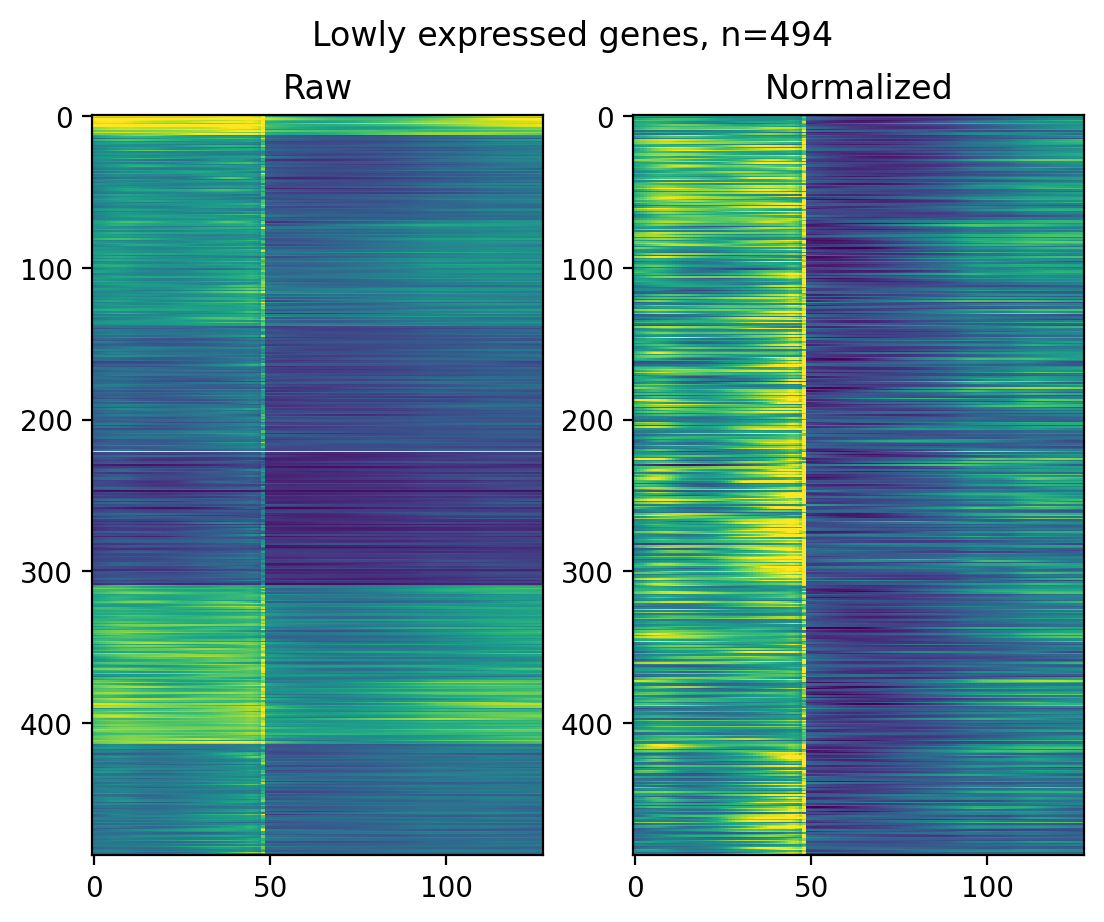

In [27]:
clustered_low_tx_gb = cluster_gb_data(normalized_low_tx_gb, low_tx_gb_nuc_occ)
plt.suptitle(f"Lowly expressed genes, n={len(low_tx_gb_nuc_occ)}")


Text(0.5, 0.98, 'Highly expressed genes, n=445')

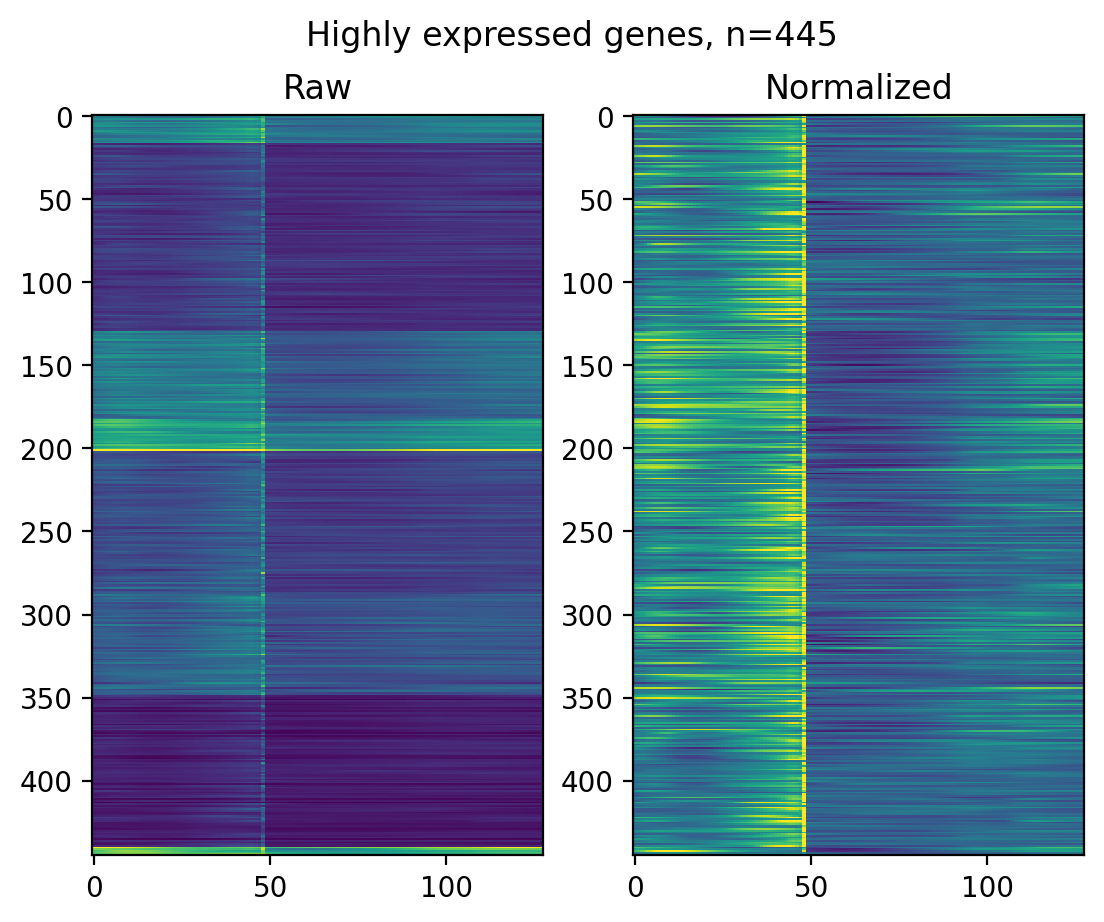

In [28]:
clustered_high_tx_gb = cluster_gb_data(normalized_high_tx_gb, high_tx_gb_nuc_occ)
plt.suptitle(f"Highly expressed genes, n={len(high_tx_gb_nuc_occ)}")

In [30]:
s_g2m_indices = gene_clustering.config.get_Hpositions_for_phase('postG1')

high_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()
low_std = low_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()

print(f"Genes with a low baseline expression, "
      f"exhibit a higher variation in nucleosome occupancy of {low_std:.2f}")
print(f"Compared to genes with high expression,"
      f"a standard deviation of {high_std:.2f}")
print(f"This appears to show that replication effects on the chromatin are clearest"
      f"with lowly expressed genes.")


Genes with a low baseline expression, exhibit a higher variation in nucleosome occupancy of 43.67
Compared to genes with high expression,a standard deviation of 21.86
This appears to show that replication effects on the chromatin are clearestwith lowly expressed genes.


In [41]:
# Idea: We could dig into individual clusters to identify which gene clusters
# defy this high level observation. Then examine which of these gene clusters
# contain the H3K56 acetylation nucleosomes.
# Compute the average H3K56 acetylation for each cluster

def compute_box_cluster_vals(clustered_tx_gb):
    from scipy.stats import pearsonr
    clusters = clustered_tx_gb.index.get_level_values(0).unique()
    box_cluster_vals = pd.DataFrame(columns=['n', 'n_acetylation', 
                                             'pearsonr', 'pearsonr_pval',
                                             'sg2m_variation', 
                                             'lower', 'median', 'upper'],
                                    index=clusters)

    for cluster in clusters:
        cluster_orfs = clustered_tx_gb.loc[cluster].index
        
        # The nucleosome variation during S-phase and G2/M
        cluster_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)
        box_cluster_vals.loc[cluster, 'sg2m_variation'] = cluster_gb_std.std()
        
        acetylation_values = genes_h3k56ac.join(pd.DataFrame(index=cluster_orfs), 
            how='inner').mean_acetylation
        
        box_vals = np.quantile(acetylation_values, q=[0.25, 0.5, 0.75])
        box_cluster_vals.loc[cluster, ['lower', 'median', 'upper']] = box_vals

        current_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)\
            .loc[acetylation_values.index]

        if len(acetylation_values) > 1:
            pearsonr_val, pval = pearsonr(acetylation_values, current_gb_std)
        else:
            pearsonr_val = np.nan
            pval = np.nan
                                       
        box_cluster_vals.loc[cluster, 'pearsonr'] = pearsonr_val
        box_cluster_vals.loc[cluster, 'pearsonr_pval'] = pval
        box_cluster_vals.loc[cluster, 'n'] = len(cluster_orfs)
        box_cluster_vals.loc[cluster, 'n_acetylation'] = len(acetylation_values)
        
    return box_cluster_vals


(-0.5, 0.7)

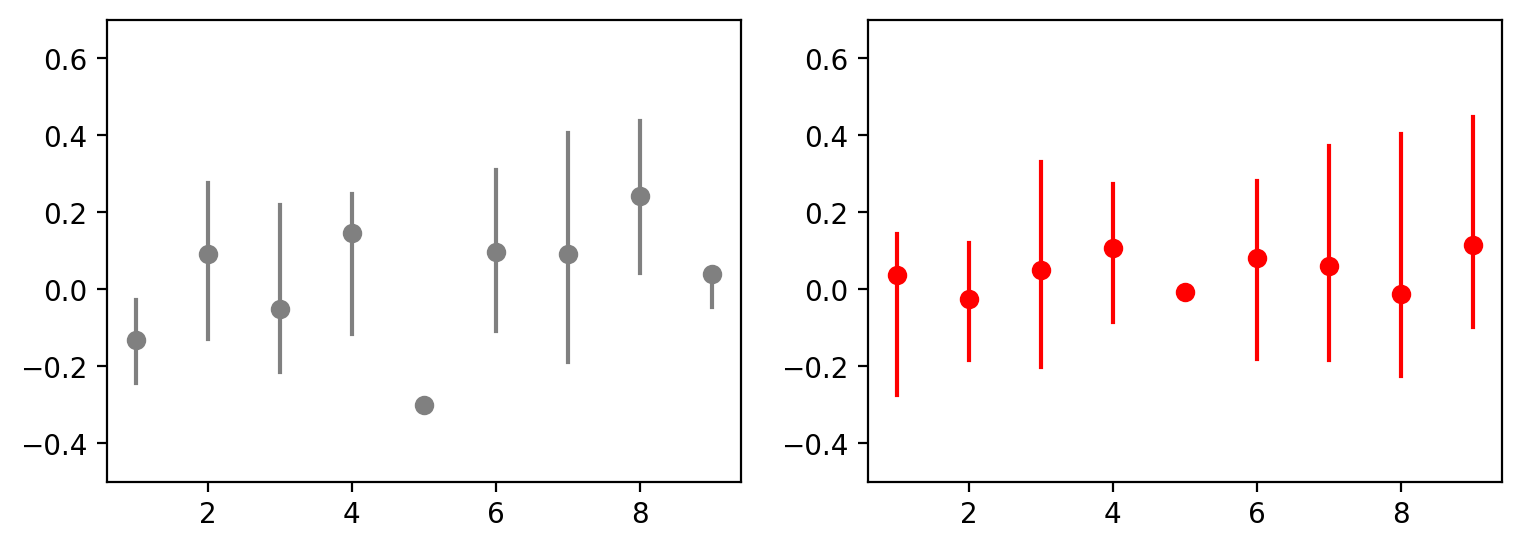

In [42]:
hi_box_cluster_vals = compute_box_cluster_vals(clustered_high_tx_gb)
low_box_cluster_vals = compute_box_cluster_vals(clustered_low_tx_gb)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
for cluster_num, row in hi_box_cluster_vals.iterrows():
    plt.scatter(cluster_num, row['median'], c='gray')
    plt.plot([cluster_num, cluster_num], 
             [row['lower'], row['upper']], c='gray')
plt.ylim(-0.5, 0.7)

plt.subplot(1, 2, 2)
for cluster_num, row in low_box_cluster_vals.iterrows():
    plt.scatter(cluster_num, row['median'], c='red')
    plt.plot([cluster_num, cluster_num], 
             [row['lower'], row['upper']], c='red')
plt.ylim(-0.5, 0.7)

In [43]:
hi_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
2,113,112,-0.088037,0.35599,9.814025,-0.129769,0.091472,0.276111
6,86,86,-0.044986,0.680864,11.008415,-0.108871,0.0963,0.308375
9,5,5,-0.023588,0.96997,37.16184,-0.04713,0.040333,0.046042
8,91,90,0.091084,0.393218,5.317085,0.042083,0.241389,0.437431
7,61,60,0.121073,0.356794,14.502708,-0.189269,0.092226,0.406269
3,53,53,0.176597,0.205887,15.358746,-0.215,-0.052083,0.219167
4,18,18,0.373088,0.127279,20.426637,-0.117423,0.145333,0.247156
1,17,16,0.452073,0.078742,16.607154,-0.245156,-0.13283,-0.028456
5,1,1,NaN,NaN,NaN,-0.300556,-0.300556,-0.300556


In [44]:
low_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
8,42,40,-0.255694,0.111279,32.2005,-0.225792,-0.014049,0.402303
6,87,84,-0.109985,0.319275,13.57511,-0.1825,0.08048,0.281329
7,63,62,-0.092188,0.476072,25.346689,-0.184271,0.060703,0.371376
3,70,70,-0.085288,0.482679,27.011952,-0.201918,0.049702,0.329833
9,73,72,-0.06714,0.575229,16.301716,-0.099167,0.115583,0.446667
4,82,80,-0.006866,0.951802,15.083835,-0.084792,0.105489,0.272292
1,13,12,0.095857,0.766967,28.014223,-0.275625,0.036319,0.14235
2,56,54,0.095987,0.489912,19.018685,-0.18441,-0.026833,0.119395
5,1,1,NaN,NaN,NaN,-0.007143,-0.007143,-0.007143


In [69]:
def compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ):
    
    gb_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1)
    gb_q10 = high_tx_gb_nuc_occ[s_g2m_indices].quantile(q=0.1, axis=1)
    gb_q90 = high_tx_gb_nuc_occ[s_g2m_indices].quantile(q=0.9, axis=1)
    
    gb_s_start = high_tx_gb_nuc_occ[s_g2m_indices[10]]
    gb_g2m_end = high_tx_gb_nuc_occ[s_g2m_indices[-10]]
    
    cur_gene_acetylation = high_tx_gb_nuc_occ[[]].join(genes_h3k56ac, 
        how='left').mean_acetylation
    compare_gb_nuc_df = pd.DataFrame({'gene_body_std': gb_std, 
                                      'gene_body_q10': gb_q10,
                                      'gene_body_q90': gb_q90,
                                      'gene_body_s_start': gb_s_start,
                                      'gene_body_g2m_end': gb_g2m_end,
        'h3k56acetylation': cur_gene_acetylation})
    return compare_gb_nuc_df


In [70]:
high_gb_nuc_df = compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ)
low_gb_nuc_df = compute_compare_gb_h3k56ac(low_tx_gb_nuc_occ)


In [52]:
#selected_cluster = 8
#selected_orfs = clustered_low_tx_gb.loc[selected_cluster].index
#selected_data = low_gb_nuc_df.loc[selected_orfs]

selected_cluster = 1
selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
selected_data = high_gb_nuc_df.loc[selected_orfs]

Text(0.5, 1.0, 'Variation in nucleosome occupancy\nvs H3K56 acetylation')

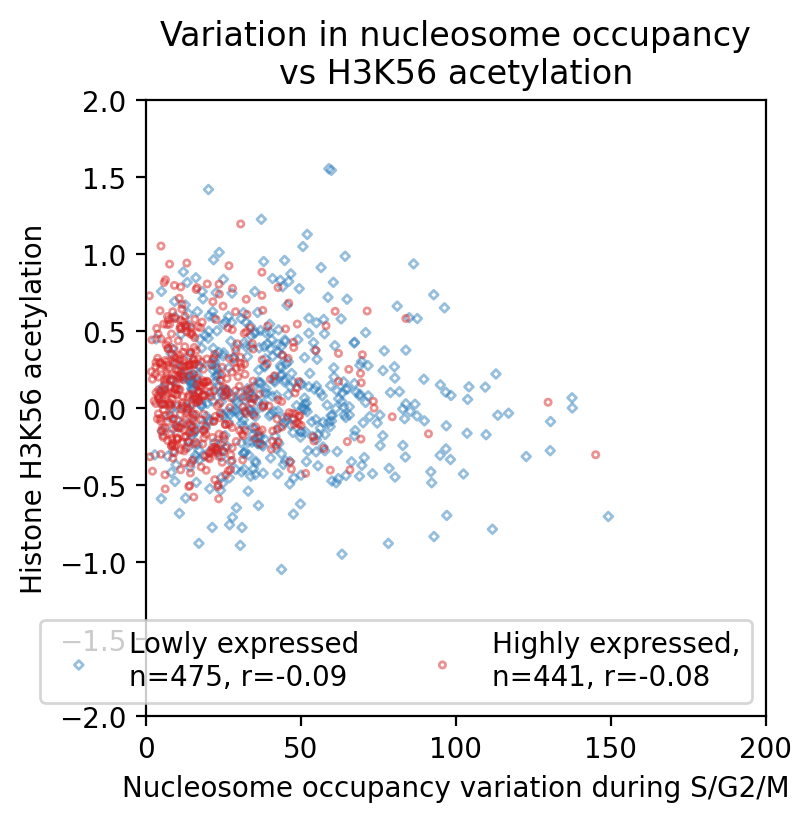

In [61]:
from scipy.stats import pearsonr

plt.figure(figsize=(4, 4))
x, y = low_gb_nuc_df.dropna().gene_body_std, \
    low_gb_nuc_df.dropna()['h3k56acetylation']
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y,
           label=f"Lowly expressed\nn={len(x)}, r={pearsonr_res:.2f}", 
            marker='D', facecolor='none',
           edgecolor=plt.get_cmap("Blues")(0.7), alpha=0.5, s=5)

x, y = high_gb_nuc_df.dropna().gene_body_std, \
    high_gb_nuc_df.dropna()['h3k56acetylation']
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y, 
            label=f"Highly expressed,\nn={len(x)}, "
                  f"r={pearsonr_res:.2f}", 
            edgecolor=plt.get_cmap('Reds')(0.7),
            facecolor='none', marker='o', alpha=0.5, s=5)

# plt.scatter(selected_data.gene_body_std, selected_data['h3k56acetylation'],
#           label=f"Selected cluster {selected_cluster}", marker='X', 
#            color='black', edgecolor='none', lw=1, alpha=1, s=15)

plt.xlabel("Nucleosome occupancy variation during S/G2/M")
plt.ylabel("Histone H3K56 acetylation")
plt.legend(loc='lower right', ncol=2)

plt.xlim(0, 200)
plt.ylim(-2, 2)
plt.title("Variation in nucleosome occupancy\nvs H3K56 acetylation")

In [58]:
from src.panther_go import PantherDBGO

panthergo = PantherDBGO()

cluster_go_df = pd.DataFrame()
for selected_cluster in np.arange(n_clusters)+1:

    selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
    selected_gene_names = genes.loc[selected_orfs]['gene']

    panthergo.run_go(selected_gene_names)
    panthergo.parse_response()
    go_results = panthergo.results_df.sort_values('fdr')

    go_results['cluster'] = selected_cluster
        
    cluster_go_df = pd.concat([cluster_go_df, go_results])


In [59]:
cluster_go_df

,id,label,number_in_list,number_in_reference,expected,fold_enrichment,fdr,pValue,cluster
0,GO:0006412,translation,64,372,7.918812,8.082021,9.096955e-41,1.931003e-44,2
1,GO:0002181,cytoplasmic translation,42,151,3.214356,13.066379,7.811998e-34,3.316493e-37,2
2,GO:1901566,organonitrogen compound biosynthetic process,79,878,18.690099,4.226837,5.567164e-32,3.545212e-35,2
3,GO:0009058,biosynthetic process,104,2122,45.171287,2.302348,9.853093e-24,8.366031e-27,2
4,GO:0044249,cellular biosynthetic process,97,1915,40.764851,2.379501,9.922583e-22,1.053129e-24,2
...,...,...,...,...,...,...,...,...,...
86,GO:0000479,endonucleolytic cleavage of tricistronic rRNA ...,6,58,1.004950,5.970443,2.475161e-02,4.570984e-04,8
87,GO:0016051,carbohydrate biosynthetic process,6,60,1.039604,5.771429,2.943258e-02,5.497914e-04,8
88,GO:0051084,'de novo' post-translational protein folding,4,24,0.415842,9.619048,3.665331e-02,6.924527e-04,8
89,GO:0034655,nucleobase-containing compound catabolic process,11,203,3.517327,3.127375,3.754131e-02,7.171976e-04,8


In [62]:
# High acetylation, high expression -> low nucleosome variability
# 0 acetylation, high expression -> high nucleosome variability
sorted_high_tx_genes = high_gb_nuc_df.sort_values('h3k56acetylation').dropna()
high_acetyl_high_tx_genes = sorted_high_tx_genes.head(100)
low_acetyl_high_tx_genes = sorted_high_tx_genes.tail(100)


In [66]:
high_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(high_acetyl_high_tx_genes, padding=1000,
                                              center_mode='+1')

low_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(low_acetyl_high_tx_genes, padding=1000,
                                              center_mode='+1')



Text(0.5, 0.98, 'Highly expressed, high acetylation genes, n=100')

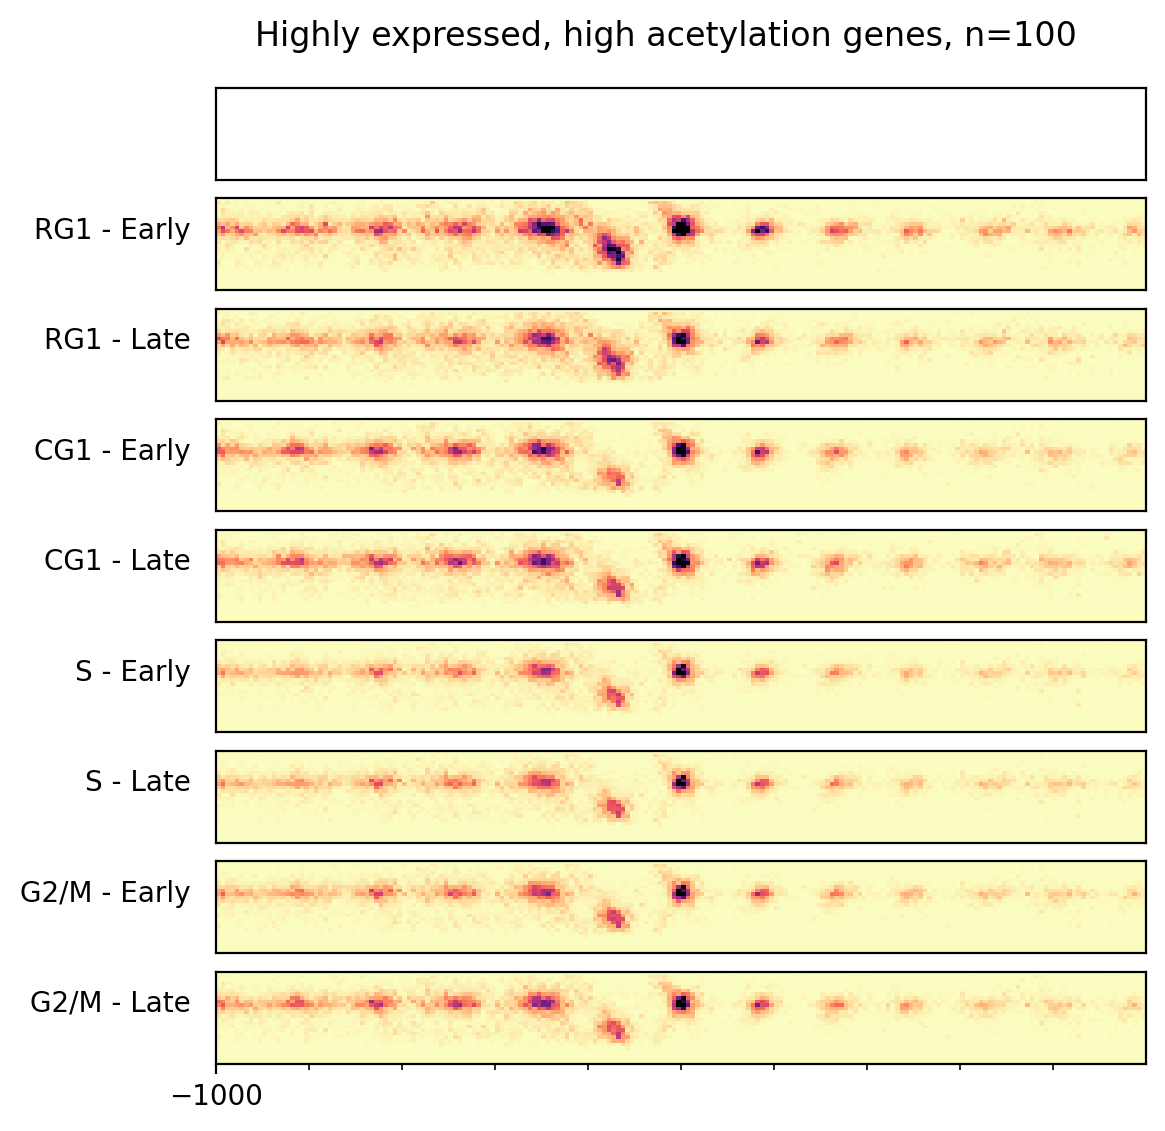

In [67]:
fig = analysis.plot_deconvolved_result(high_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, high acetylation genes, n={len(high_acetyl_high_tx_genes)}")

Text(0.5, 0.98, 'Highly expressed, low acetylation genes, n=100')

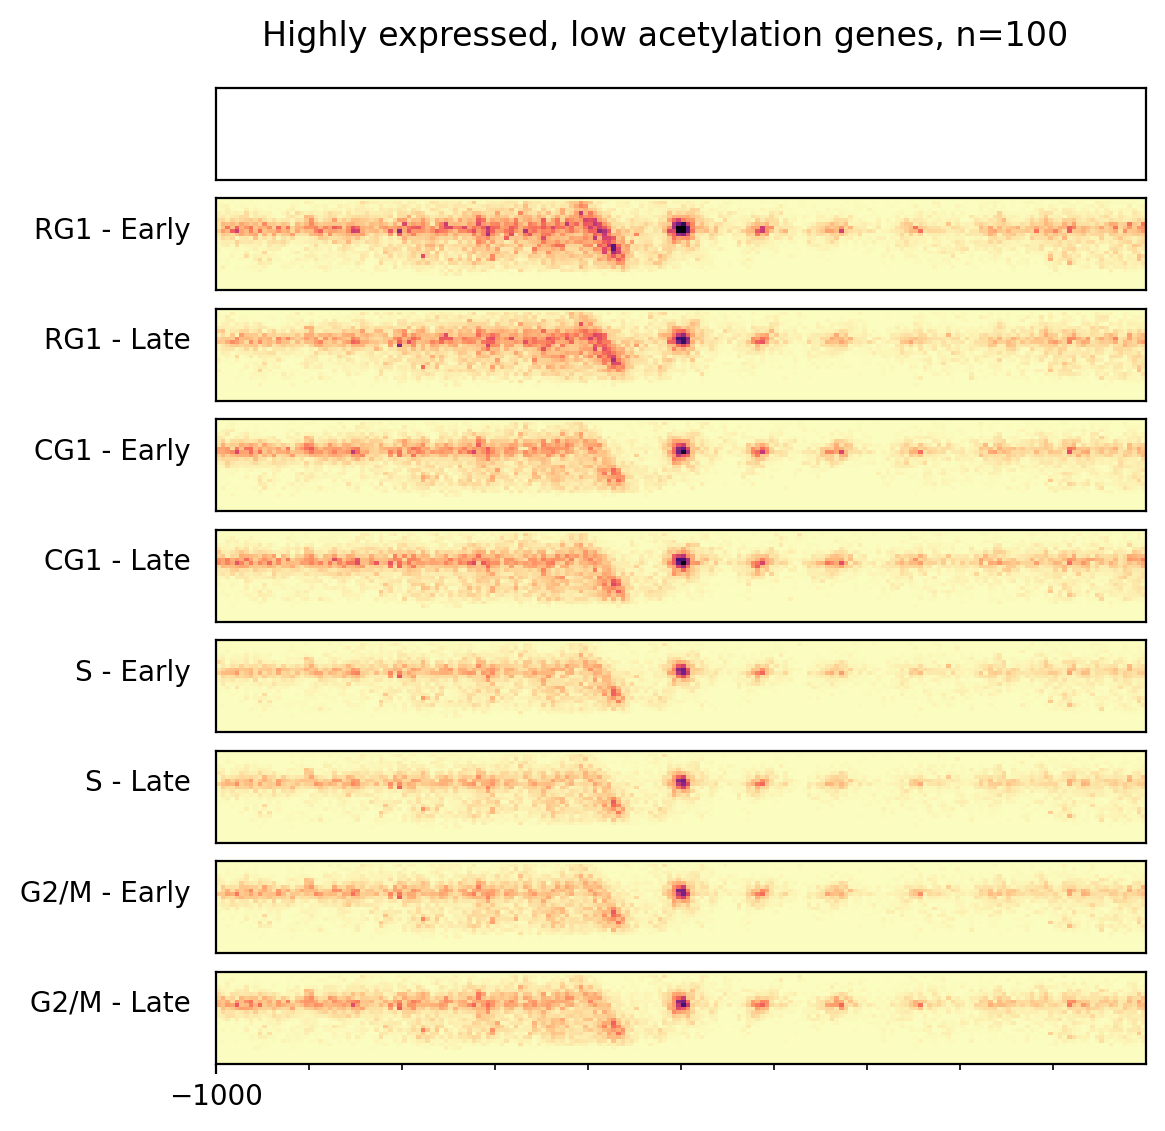

In [68]:
fig = analysis.plot_deconvolved_result(low_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, low acetylation genes, n={len(low_acetyl_high_tx_genes)}")

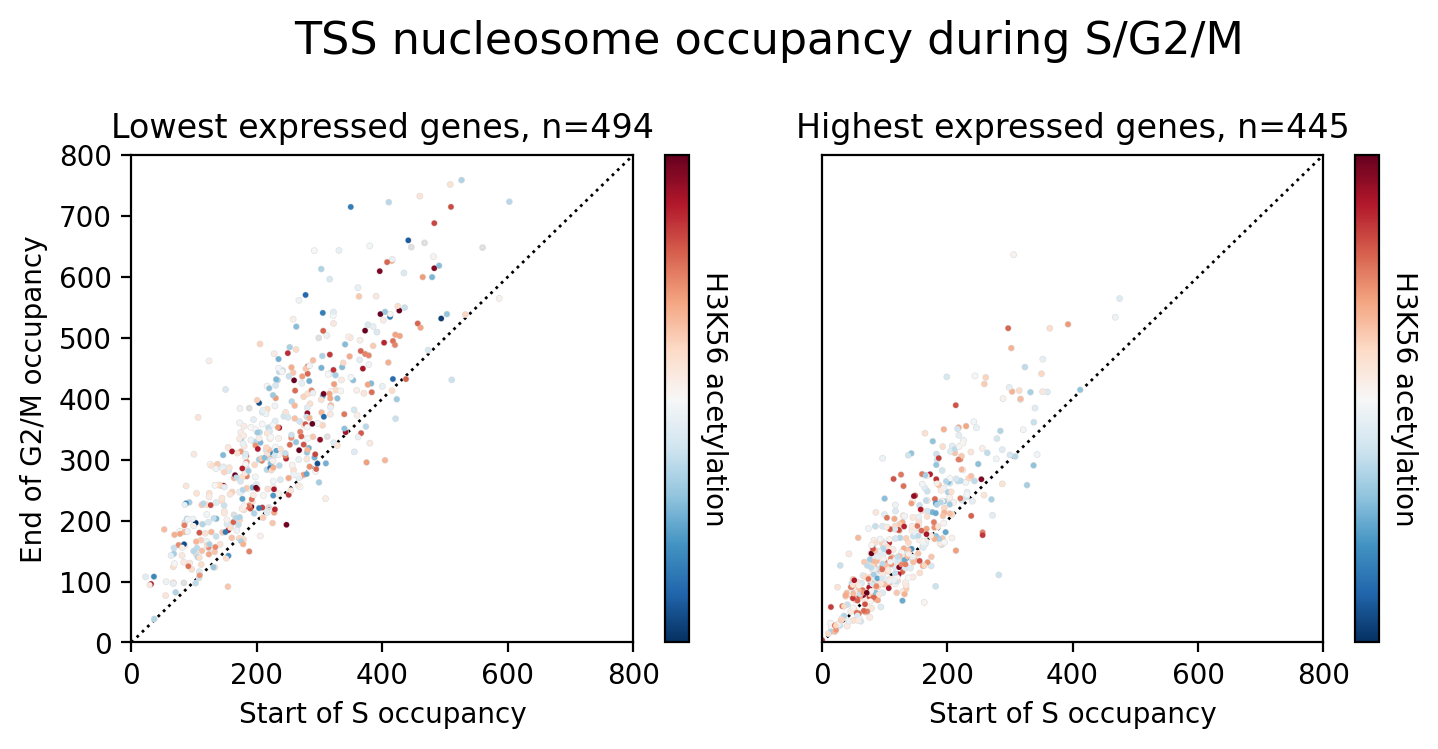

In [84]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

plt.figure(figsize=(8.5, 3.75))
plt.subplot(1, 2, 2)
plt.scatter(high_gb_nuc_df.gene_body_s_start, high_gb_nuc_df.gene_body_g2m_end, s=2,
           edgecolor='#dddddd', facecolor='none')
plt.scatter(high_gb_nuc_df.gene_body_s_start, high_gb_nuc_df.gene_body_g2m_end, s=1,
           c=high_gb_nuc_df.h3k56acetylation, vmax=1, vmin=-1, cmap='RdBu_r')
plt.xlabel("Start of S occupancy")
plt.title(f"Highest expressed genes, n={len(high_gb_nuc_df)}")
plt.ylim(0, 800)
plt.xlim(0, 800)
plt.yticks([])
cbar = plt.colorbar()
cbar.ax.set_yticks([])
plt.plot([0, 1000], [0, 1000], c='black', lw=1, ls='dotted', zorder=0)
cbar.ax.set_ylabel("H3K56 acetylation", rotation=270, va='bottom')

plt.subplot(1, 2, 1)
plt.scatter(low_gb_nuc_df.gene_body_s_start, low_gb_nuc_df.gene_body_g2m_end, s=2,
           edgecolor='#dddddd', facecolor='none')
plt.scatter(low_gb_nuc_df.gene_body_s_start, low_gb_nuc_df.gene_body_g2m_end, s=1,
           c=low_gb_nuc_df.h3k56acetylation, vmax=1, vmin=-1, cmap='RdBu_r')
cbar = plt.colorbar()
cbar.ax.set_yticks([])
cbar.ax.set_ylabel("H3K56 acetylation", rotation=270, va='bottom')

plt.title(f"Lowest expressed genes, n={len(low_gb_nuc_df)}")
plt.xlabel("Start of S occupancy")
plt.ylabel("End of G2/M occupancy")
plt.ylim(0, 800)
plt.xlim(0, 800)
plt.plot([0, 1000], [0, 1000], c='black', lw=1, ls='dotted', zorder=0)
plt.suptitle("TSS nucleosome occupancy during S/G2/M", 
    fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
plt.subplots_adjust(top=0.8, wspace=0.1, bottom=0.15)
save_figure_for_paper("output/figures/Buffering/TSS_occupancy.png")